# Tutorial Part 1: Interpretable Machine Learning and Input Sensitivity
## Case Study: The MNIST Benchmark and Convolutional Geometric Priors
### Audience: Mathematical Biology & Applied Mathematics (Colab-Native Workflow)

---

## 🎯 Executive Discovery Summary: What We Will Learn
In this mini-tutorial, we shift from regarding artificial neural networks as opaque, black-box systems to examining them as **differentiable multivariate vector functions**. We will discover how structural mathematical choices in network design fundamentally alter the stability, continuity, and interpretability of a model's local sensitivity landscape.

### Core Concepts to Uncover:
1. **The Gradient as a Sensitivity Operator:** If a model outputs a probability score $S_c(\mathbf{x})$ for a target class $c$ given an image vector $\mathbf{x}$, the local Jacobian vector $\nabla_{\mathbf{x}} S_c(\mathbf{x}_0)$ acts as a first-order sensitivity coefficient. It reveals exactly how a localized perturbation to any single pixel coordinate will scale the final functional output.
2. **Architecture as a Spatial Regularizer:** We will explore how changing the underlying architecture from a Multi-Layer Perceptron (MLP) to a Convolutional Neural Network (CNN) changes the gradient from discontinuous, high-frequency "television static" noise into cohesive topological regions. We will see firsthand that a convolution kernel acts as a powerful mathematical prior enforcing spatial correlation.
3. **Anatomical Feature Extraction:** By isolating the top 5% of most sensitive coordinates and projecting them as a contour boundary back onto our raw data inputs, we will identify the precise continuous structural boundaries (such as loops and open gaps) that drive the model's classification decisions.

### ⚙️ Computational Tuning for a 2-Hour Flow
To maximize pedagogical clarity and preserve tutorial velocity, we downsample standard MNIST observations from a $28 \times 28$ matrix to a mid-scale $20 \times 20$ grid. This modification balances structural fidelity (preserving fine strokes) with a tiny parameter footprint (~24,000 coefficients), allowing full model convergence in under 15 seconds natively inside Google Colab without requiring manual package installations.

| Dimensional Metric | Standard MNIST Baseline | Our Pedagogical Layout |
| :--- | :--- | :--- |
| **Data Subsampling Pool** | 60,000 Train / 10,000 Test | 10,000 Train / 2,000 Test (Stratified) |
| **Spatial Resolution** | $28 \times 28 = 784$ features | $\mathbf{20 \times 20 = 400}$ features |
| **Structural Resolution** | High Fidelity | Optimized Continuous Smooth Contours |
| **Total Parameter Scale** | ~235,000 weights/biases | **~24,000 weights/biases** |
| **Colab Execution Latency** | ~2–3 Minutes | **~10–15 Seconds** |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Environment Confirmed. Target Version:", tf.__version__)

# Lock global pseudorandom seeds to ensure identical optimization trajectory across student runtimes
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow Environment Confirmed. Target Version: 2.21.0


## 1. Data Geometry: Stratification, Downsampling, and Vector Scaling

To maintain a controlled learning pace, we read the raw MNIST database and build a perfectly stratified partition containing exactly 1,000 training inputs and 200 verification inputs for each discrete digit class ($0, 1, \dots, 9$). 

Mathematically, we transform the original $28 \times 28$ structural grids down to a crisp $20 \times 20$ grid using a bilinear resizing operator $\mathcal{R}: \mathbb{R}^{28 \times 28} \to \mathbb{R}^{20 \times 20}$. Finally, we rescale discrete grayscale integer intensities from the bounded boundary $[0, 255]$ into a continuous compact interval $[0, 1] \subset \mathbb{R}$.

In [2]:
# 1. Load the native raw pixel arrays
(x_train_full, g_train_full), (x_test_full, g_test_full) = keras.datasets.mnist.load_data()

# 2. Define uniform stratified index sampling to isolate balanced class pools
def build_stratified_subset(images, labels, samples_per_class, seed=280):
    rng = np.random.default_rng(seed)
    selected_indices = np.concatenate([
        rng.choice(np.where(labels == digit)[0], size=samples_per_class, replace=False)
        for digit in range(10)
    ])
    rng.shuffle(selected_indices) # Scramble sequence blocks
    return images[selected_indices], labels[selected_indices]

x_train_raw, y_train = build_stratified_subset(x_train_full, g_train_full, samples_per_class=1000)
x_test_raw, y_test = build_stratified_subset(x_test_full, g_test_full, samples_per_class=200)

# 3. Execute Bilinear Scaling to Mid-Scale Resolution (28x28 -> 20x20)
x_train_20x20 = tf.image.resize(np.expand_dims(x_train_raw, axis=-1), (20, 20)).numpy().squeeze()
x_test_20x20 = tf.image.resize(np.expand_dims(x_test_raw, axis=-1), (20, 20)).numpy().squeeze()

# 4. Apply Linear Intensity Normalization
x_train = x_train_20x20 / 255.0
x_test = x_test_20x20 / 255.0

print(f"Optimized Training Tensor Geometry: {x_train.shape}")
print(f"Optimized Verification Tensor Geometry: {x_test.shape}")

Optimized Training Tensor Geometry: (10000, 20, 20)
Optimized Verification Tensor Geometry: (2000, 20, 20)


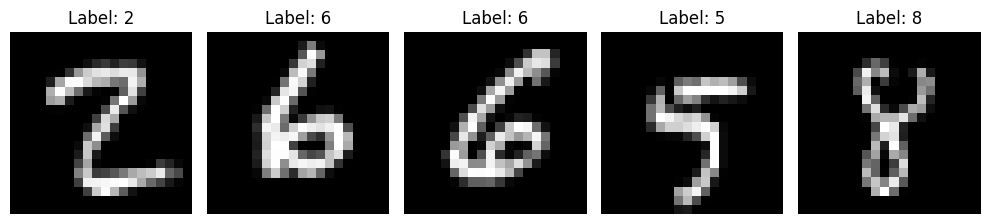

In [3]:
# Verify structural resolution of downsampled samples
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i in range(5):
    axes[i].imshow(x_train[i], cmap='gray')
    axes[i].set_title(f"Label: {y_train[i]}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 2. Geometric Prior: The Mathematics of Convolutional Architecture

In standard Fully Connected layers (Multi-Layer Perceptrons), an image is flattened into a one-dimensional array, discarding spatial adjacency information. Every input node maps to every hidden neuron via independent scalar weights, enabling adjacent pixel sensitivities to vary wildly and independently.

A **Convolutional Neural Network (CNN)** addresses this by enforcing a structural geometric prior directly into the functional composition using space-invariant operations. Instead of mapping independent weights to each coordinate, a compact localized kernel matrix $\mathbf{K} \in \mathbb{R}^{3 \times 3}$ slides systematically across the discrete 2D spatial coordinates:

$$Z_{i,j} = \sum_{m=-1}^{1} \sum_{n=-1}^{1} X_{i+m, j+n} \cdot K_{m,n} + b$$

### Mathematical Consequences of the Convolution Prior:
1. **Weight Sharing:** Because the same localized matrix parameters $K_{m,n}$ generate elements across the output feature grid, adjacent inputs share common transformation parameters.
2. **Spatial Regularization of the Jacobian:** When backpropagation executes via the multi-variable chain rule, the tracking of partial derivatives passes directly through these shared spatial kernels. This forces a strong local correlation onto the input gradient vector, naturally regularizing the sensitivity map into smooth, continuous fields rather than isolated pixel static.

In [4]:
def compile_compact_cnn():
    model = keras.Sequential([
        # 1. Structural Reshape: Inject singleton channel dimension to form a proper spatial tensor (20, 20, 1)
        layers.Reshape((20, 20, 1), input_shape=(20, 20)),
        
        # 2. Convolution Operator: 8 distinct 3x3 sliding spatial kernels
        layers.Conv2D(8, kernel_size=(3, 3), activation='relu', name='Spatial_Conv_1'),
        
        # 3. Max Pooling Operator: Subsamples 2x2 blocks to extract local translation invariance
        layers.MaxPooling2D(pool_size=(2, 2), name='Max_Subsample_1'),
        
        # 4. Spatial Unrolling
        layers.Flatten(name='Vector_Unroll'),
        
        # 5. Hidden Mixing Dense Layer
        layers.Dense(32, activation='relu', name='Hidden_Mixing'),
        
        # 6. Terminal Softmax Classifier: Projects outputs onto the standard probability simplex
        layers.Dense(10, activation='softmax', name='Output_Projections')
    ], name="Compact_Pedagogical_CNN")
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.005),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = compile_compact_cnn()
cnn_model.summary()

/Users/suzannesindi/miniforge3/lib/python3.12/site-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Compact_Pedagogical_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 20, 20, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Spatial_Conv_1 (Conv2D)         │ (None, 18, 18, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Subsample_1 (MaxPooling2D)  │ (None, 9, 9, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Vector_Unroll (Flatten)         │ (None, 648)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_Mixing (Dense)           │ (None, 32)             │        20,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Projections (Dense)      │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,178 (82.73 KB)

 Trainable params: 21,178 (82.73 KB)

 Non-trainable params: 0 (0.00 B)

Executing fast CNN model optimization routine...
Epoch 1/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8028 - loss: 0.6500 - val_accuracy: 0.9235 - val_loss: 0.2862
Epoch 2/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9307 - loss: 0.2367 - val_accuracy: 0.9480 - val_loss: 0.1903
Epoch 3/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9504 - loss: 0.1656 - val_accuracy: 0.9545 - val_loss: 0.1508
Epoch 4/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9636 - loss: 0.1279 - val_accuracy: 0.9630 - val_loss: 0.1281
Epoch 5/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9703 - loss: 0.1021 - val_accuracy: 0.9645 - val_loss: 0.1158
Epoch 6/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9764 - loss: 0.0851 - val_accuracy: 0.9665 - val_loss: 0.1085
Epoch 7/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9799 - loss: 0.0718 - val_accuracy: 0.9670 - val_loss: 0.1035
Epoch 8/12
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9827 

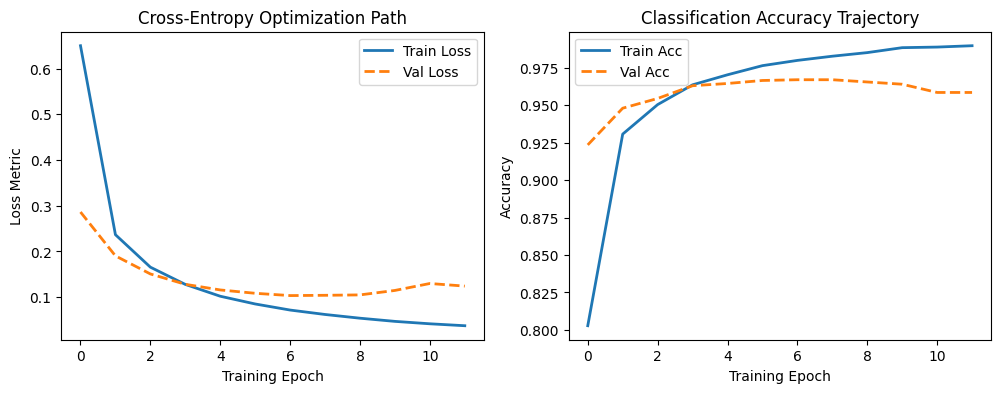

In [5]:
# Train model parameters
print("Executing fast CNN model optimization routine...")
history = cnn_model.fit(
    x_train, y_train,
    epochs=12,
    batch_size=128,
    validation_data=(x_test, y_test),
    verbose=1
)

# Plot validation diagnostic curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss', lw=2)
ax1.plot(history.history['val_loss'], label='Val Loss', lw=2, linestyle='--')
ax1.set_title("Cross-Entropy Optimization Path")
ax1.set_xlabel("Training Epoch")
ax1.set_ylabel("Loss Metric")
ax1.legend()

ax2.plot(history.history['accuracy'], label='Train Acc', lw=2)
ax2.plot(history.history['val_accuracy'], label='Val Acc', lw=2, linestyle='--')
ax2.set_title("Classification Accuracy Trajectory")
ax2.set_xlabel("Training Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
plt.show()

## 3. Post-Hoc Sensitivity Mapping: The Input Gradient Vector

To analyze why our model outputs a specific categorical decision, we evaluate a local first-order **Taylor series expansion** at the coordinates of an isolated image vector $\mathbf{x}_0$. If we disturb the baseline image by a localized shift vector $\mathbf{\Delta x}$, the transformation of the class confidence score $S_c(\mathbf{x}_0)$ is governed by:

$$S_c(\mathbf{x}_0 + \mathbf{\Delta x}) \approx S_c(\mathbf{x}_0) + \left[ \nabla_{\mathbf{x}} S_c(\mathbf{x}_0) \right]^T \mathbf{\Delta x}$$

The spatial vector gradient operator contains the system's local sensitivity coefficients:

$$\nabla_{\mathbf{x}} S_c(\mathbf{x}_0) = \left[ \frac{\partial S_c(\mathbf{x}_0)}{\partial x_{i,j}} \right] \in \mathbb{R}^{20 \times 20}$$

By evaluating the absolute value of these spatial components, we build a **Vanilla Saliency Map** bounded on the positive real space $[0, +\infty)$:

$$\text{Saliency}_{i,j} = \left| \frac{\partial S_c(\mathbf{x}_0)}{\partial x_{i,j}} \right|$$

### 📊 The Inter-Image Normalization Problem
Because a neural network is non-linear, absolute gradient scales vary unpredictably between distinct images based on local flatness. To resolve this, we normalize each image independently using a **Robust Percentile Scaler**. We compute the 95th percentile threshold ($\mathcal{P}_{95}$) of the local gradient intensities, clip structural outlier noise spikes, and scale features cleanly between $[0, 1]$ relative to that local threshold baseline. This reveals the structural features that matter most to that specific configuration.

In [6]:
def compute_input_saliency(model, image, target_class):
    """
    Evaluates the localized absolute input gradient matrix for a chosen observation vector 
    utilizing TensorFlow's programmatic automatic differentiation engine.
    """
    # 1. Convert input to a continuous floating tensor representation
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    
    # 2. Append singleton batch axis required by Keras layout: (20, 20) -> (1, 20, 20)
    image_tensor = tf.expand_dims(image_tensor, axis=0)
    
    # 3. Intercept computational graph execution with GradientTape
    with tf.GradientTape() as tape:
        tape.watch(image_tensor)
        
        # Execute the forward mapping pass
        predictions = model(image_tensor)
        
        # Isolate the activation value for the target category node
        class_score = predictions[0, target_class]
        
    # 4. Backward Pass: Compute partial derivative matrix d(Score)/d(Image)
    gradient = tape.gradient(class_score, image_tensor)
    
    # 5. Collapse the batch dimensions and evaluate the absolute component value
    absolute_saliency = tf.squeeze(tf.abs(gradient)).numpy()
    
    return absolute_saliency

## 4. Visualizing Features: 3-Column Region Contour Tracking

We now visualize our results across three structural perspectives:
1. **Column 1 (The Normalized Input Space):** The continuous downsampled $20 \times 20$ input image.
2. **Column 2 (The Sensitivity Field):** The robustly scaled input gradient heatmap, displayed using the `'hot'` colormap layout.
3. **Column 3 (The Salient Sub-Structure):** We calculate a binary importance mask identifying coordinates falling in the **top 5% of highest importance values** ($\ge \mathcal{P}_{95}$). We use a 2D contour tracer to draw a bright green (`'lime'`) outline directly on top of the original grayscale handwriting, exposing the structural regions that guide the network's decisions.

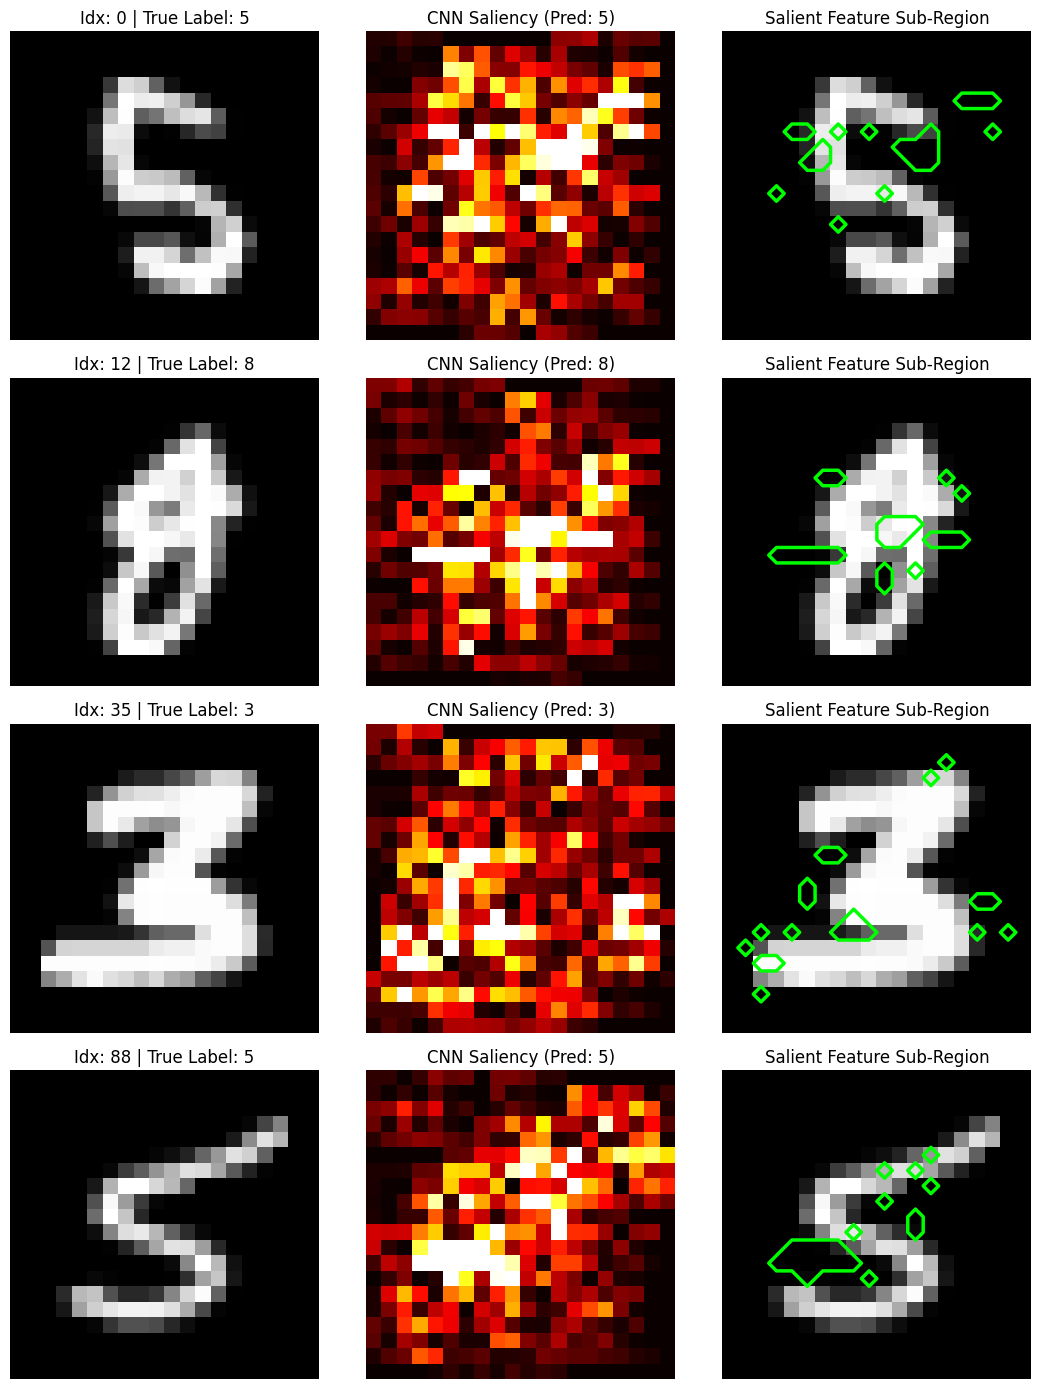

In [7]:
# Select identical testing indices to maintain benchmark continuity
sample_indices = [0, 12, 35, 88] 

# Set up a 3-column matrix display
fig, axes = plt.subplots(len(sample_indices), 3, figsize=(11, 3.5 * len(sample_indices)))

for step, idx in enumerate(sample_indices):
    test_img = x_test[idx]
    true_label = y_test[idx]
    
    # 1. Evaluate categorical class predictions via the CNN
    pred_probabilities = cnn_model.predict(tf.expand_dims(test_img, axis=0), verbose=0)
    predicted_class = np.argmax(pred_probabilities)
    
    # 2. Extract the raw absolute input sensitivities
    saliency_map = compute_input_saliency(cnn_model, test_img, predicted_class)
    
    # 3. Apply Robust Scaling (clip at local 95th percentile, scale between 0 and 1)
    v_max = np.percentile(saliency_map, 95)
    clipped_saliency = np.clip(saliency_map, 0, v_max)
    normalized_saliency = clipped_saliency / (v_max + 1e-8)
    
    # 4. Construct the Binary Importance Mask for the top 5% most sensitive pixels
    importance_threshold = np.percentile(saliency_map, 95)
    importance_mask = (saliency_map >= importance_threshold).astype(float)
    
    # --- Column 1: Normalized Image Matrix ---
    axes[step, 0].imshow(test_img, cmap='gray')
    axes[step, 0].set_title(f"Idx: {idx} | True Label: {true_label}")
    axes[step, 0].axis('off')
    
    # --- Column 2: Saliency Vector Heatmap ---
    im = axes[step, 1].imshow(normalized_saliency, cmap='hot', vmin=0, vmax=1)
    axes[step, 1].set_title(f"CNN Saliency (Pred: {predicted_class})")
    axes[step, 1].axis('off')
    
    # --- Column 3: Feature Region Contour Overlay ---
    axes[step, 2].imshow(test_img, cmap='gray')
    # Draw a green contour boundary tracking the edges of our binary mask
    axes[step, 2].contour(importance_mask, levels=[0.5], colors='lime', linewidths=2.5)
    axes[step, 2].set_title("Salient Feature Sub-Region")
    axes[step, 2].axis('off')

plt.tight_layout()
plt.show()

## 5. Classroom Discussion and Analytic Extensions

### Analytical Questions for Applied Math Students:
1. **Topology of the Contour Lines:** Observe the green contours in the third column. Notice that they do not simply trace the center of the drawn line. Instead, they often isolate structural features like internal loops or open gaps. Why does an empty gap (such as the left side of a `3`) carry high local sensitivity when discriminating between similar digits (like a `3` versus an `8`)?
2. **The Spatial Smoothness Transformation:** If you compare these results to an unregularized Multi-Layer Perceptron (MLP), the MLP's saliency maps resemble random pixel noise. Explain how the weight-sharing structure of a convolutional kernel translates mathematically into a spatial low-pass filter on the network's input gradient vector.
3. **Connecting Image Sensitivity to Dynamical Systems:** In mathematical biology, we use **parametric sensitivity analysis** to compute how state variables shift relative to parameter changes (e.g., evaluating the sensitivity coefficient matrix $\frac{\partial \mathbf{y}}{\partial \mathbf{p}}$ in biochemical pathways). How does tracking input sensitivity gradients in a neural network mirror analyzing parametric sensitivities to locate the critical drivers of a phase transition or a system bifurcation?